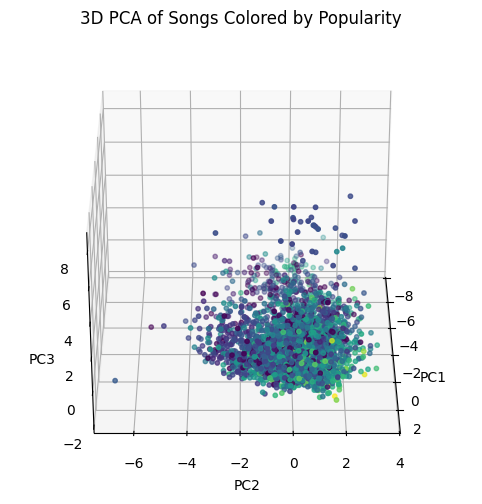

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
import re

df = pd.read_csv("dataset.csv")

def normalize_string(s):
    return re.sub(r'\W+', ' ', str(s)).strip().lower()

df['duration_sec'] = df['duration_ms'] / 1000

features = [
    'popularity', 'duration_sec', 'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo'
]
# Reduce size
df_clean = df[features].dropna().sample(n=3000, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

pca = PCA(n_components=3)
pca_result = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(pca_result[:, 0], pca_result[:, 1], pca_result[:, 2],
                c=df_clean['popularity'], cmap='viridis', s=10)

ax.set_title("3D PCA of Songs Colored by Popularity")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

# Animate
def rotate(angle):
    ax.view_init(30, angle)

ani = animation.FuncAnimation(fig, rotate, frames=np.arange(0, 360, 4), interval=50)
ani.save("images/pca_3d_rotation.gif", writer='pillow', fps=10)
